In [1]:
import re
import numpy as np
import pandas as pd
import collections
import matplotlib.pyplot as plt
import networkx as nx
# import node2vec
from treelib import Node, Tree
from collections import Iterable
from collections import Counter
import math
plt.rcParams['font.sans-serif']=['SimHei']
# plt.rcParams['figure.figsize']=['10', '10']
# plt.rcParams['axes.unicode_minus']=False

In [2]:
class Label(object):
    def __init__(self, layer, read, stay, color):
        self.layer = layer
        self.count = 1
        self.read = read
        self.stay = stay
        self.color = color

In [3]:
# root here is str
def sum_up(tree,root):
    children_list=tree.children(root)
    if len(children_list)>0:
        for i in children_list:
            t = sum_up(tree,i.identifier)
            tree.nodes[root].data.read += t[0]
            tree.nodes[root].data.stay += t[1]
            
        return [tree.nodes[root].data.read, tree.nodes[root].data.read*tree.nodes[root].data.stay]
    else:
        return [tree.nodes[root].data.read, tree.nodes[root].data.read*tree.nodes[root].data.stay]

In [31]:
def article_time_period_count(data,author):
    data_1 = data[data.Author==author]
    data_1 = data_1.sort_values('Time')
    data_1 = data_1.drop_duplicates(subset=['Title'], keep='first', inplace=False)
    # min time: 2017-06-24, max time: 2018-10-10
    total_len = len(data_1)
    one_year_len = len(data_1[data_1.Time<'2018-02-24'])
    print(min(data_1.Time), one_year_len/float(total_len))
    return data_1


In [4]:
def author_tree(data,author,rate):
    data_1 = data[data.Author==author]
    data_2 = data_1.drop_duplicates(subset=['Title'], keep='first', inplace=False)
    data_2 = data_2.sort_values('Time')
    title_list = data_2.Title.tolist()
    new_titles = []
    
    total_read = sum(data_1.Read)
    cum_read = 0
    node_id = 0
    node_list = [author]
    p_node_list = [author] # Previous node list: nodes without reaching the threshold
    save_for_later = []
    save_for_later_1 = []
    tree=Tree()
    c = 0 # count for articles
    c1 = 0 # count for new points
    c2 = 0 # count for reached points
    c3 = 0 # count for reached points in new points
    tree.create_node(tag=0, identifier=0, data = Label(0,0,0,'firebrick'))
    flag = 1 # flag for reach the threshold
    for title in title_list:
        c+=1
        data_2 = data_1[data_1.Title==title]
        data_2 = data_2.sort_values('Time')
        if c > rate*len(title_list): 
            flag = 0
            n_color = 'cornflowerblue'
            c1 += len(data_2)
            new_titles.append(title)
        else: 
            n_color = 'tan'
            c2 += len(data_2)
        for index, row in data_2.iterrows():
            WNN=row.Wechat_NN
            if WNN not in node_list:
                node_id += 1
                node_list.append(WNN)
                if flag: p_node_list.append(WNN)
                if row.Layer==1: 
                    tree.create_node(tag=node_id, identifier=node_id, parent = 0, 
                    data = Label(row.Layer,row.Read,row.Read*row.Stay,n_color))
                else: 
                    try:
                        p_id=node_list.index(row.Belong2)
                        tree.create_node(tag=node_id, identifier=node_id, parent = p_id, data = Label(row.Layer,row.Read,row.Read*row.Stay,n_color))
                    except:
                        save_for_later.append([node_id,row.Belong2,row.Layer,row.Read,row.Read*row.Stay,n_color])
                            
            else:
                if flag==0: c3+=1
                try:
                    p_node_id = node_list.index(WNN)
                    tree.nodes[p_node_id].data.count+=1
                    tree.nodes[p_node_id].data.read+=row.Read
                    tree.nodes[p_node_id].data.stay+=row.Read*row.Stay
                except:
                    save_for_later_1.append([WNN,row.Read,row.Read*row.Stay])
            cum_read += row.Read
    for nid in save_for_later:
        try:
            p_id=node_list.index(nid[1])
            tree.create_node(tag=nid[0], identifier=nid[0], parent = p_id, data = Label(nid[2],nid[3],nid[4],nid[5]))
        except: continue
    for nn in save_for_later_1:
        try:
            node_id=node_list.index(nn[0])
            tree.nodes[node_id].data.count+=1
            tree.nodes[node_id].data.read+=nn[1]
            tree.nodes[node_id].data.stay+=nn[2]
        except: continue
            
    sum_up(tree,0)
    return [tree, c1, c2, c3, new_titles, p_node_list]

In [140]:
def tree_graph(tree,root):
    G = nx.Graph()
    visit=[root]
    while len(visit)>0:
        cur=visit[-1]
        if cur==root: 
            G.add_node(cur,weight=tree.nodes[cur].data.stay,c=tree.nodes[cur].data.color)
            visit.pop()
            children_list=tree.children(cur)
            for i in children_list:
                visit.append(i.identifier)  
        else:
            G.add_node(cur,weight=tree.nodes[cur].data.stay,c=tree.nodes[cur].data.color)
            G.add_edge(cur,tree.parent(cur).identifier,weight=(tree.nodes[cur].data.count))
            visit.pop()
            children_list=tree.children(cur)
            for i in children_list:
                visit.append(i.identifier) 
        
    return G


In [153]:
def compact_path(G,author,c1,c2):
    pos = nx.circular_layout(G)
    plt.clf()
    edges = G.edges()
    node_weight = []
    node_label = []
    node_color = []
    for i in list(G.nodes(data='weight')):
        node_weight.append(i[1]/30)
        node_label.append(i[1])
    for i in list(G.nodes(data='c')):
        node_color.append(i[1])
        
    edge_weight=[]
    edge_label=[]
    edge_color=[]
    for i in list(G.edges(data='weight')):
        edge_weight.append(i[2]/15)
        edge_label.append(i[2])
        if i[2]>39: edge_color.append('mediumaquamarine')
        else: edge_color.append('rosybrown')
    options = {'font_size':8,'font_weight':'ultralight',}
    node_label=dict(zip(list(G.nodes()),node_label))
    edge_label=dict(zip(list(G.edges),edge_label))
    try:
        pos = nx.nx_agraph.graphviz_layout(G)
    except:
        pos = nx.spring_layout(G, iterations=20)
        
    plt.text(-0.25, -0.2, "80%%: %d, 20%%: %d" %(c2,c1), size = 6)
    plt.text(-0.25, -0.26, "New points in 20%%: %d" %node_color.count('cornflowerblue'), size = 6)
    plt.title(author)
    node_weight=[25]+[3]*(len(G.nodes())-1)
#     nx.draw(G, pos, edges=edges,edge_color=edge_color,node_size=node_weight, node_color=node_color,labels=node_label, width=edge_weight, **options)
#     nx.draw_networkx_edge_labels(G, pos,edge_labels=edge_label,label_pos=0.5,font_size=5,font_weight='ultralight',bbox={"fc":"w","alpha":0.9,"pad":0,"edgecolor":"white"})
    nx.draw_spring(G, node_color=node_color,edge_color='lightgray',node_size=node_weight)
    plt.rcParams['figure.figsize']=8, 8
    plt.savefig("CommonPath/Compact_Path_%s.png" %author, format="PNG",dpi=600)

In [142]:
def new_path(data, author, new_titles,node_list):
    data_0=data[data.Author==author]
    ct = 0
    for title in new_titles:
        data_1=data_0[data_0.Title==title]
        G = nx.Graph()
        G.add_node(author)
        max_layer=max(data_1.Layer)
        visited=[]
        layer_list=[]
        node_color=['firebrick']
        # max_layer
        for layer in range(1,max_layer+1):
            for index, row in data_1.iterrows():
                if row.Layer==layer and row.Wechat_NN not in visited:
                    if row.Wechat_NN in node_list: node_color.append('tan')
                    else: node_color.append('cornflowerblue')
                    if layer==1:
                        G.add_node(row.Wechat_NN, layer=layer)
                        G.add_edge(row.Wechat_NN, author)
                        layer_list.append(layer)
                    else:
                        try:
                            parent_layer=layer_list[visited.index(row.Belong2)]
                        except:
                            parent_layer=layer-1
                        G.add_node(row.Wechat_NN, layer=parent_layer)
                        G.add_edge(row.Wechat_NN,row.Belong2)
                        layer_list.append(parent_layer)
                    visited.append(row.Wechat_NN)
        node_size=[25]+[10]*(len(G.nodes())-1)
        plt.figure()
        nx.draw_spring(G, node_color=node_color,edge_color='lightgray',node_size=node_size)
        plt.rcParams['figure.figsize']=4, 4
        plt.savefig("CommonPath/%s_%d_%s.png" %(author,ct,title), format="PNG",dpi=500,facecolor='w')
        ct+=1

In [5]:
data = pd.read_csv("mingjiang/detail_new.csv")
data.columns=["Auto_Index","Title","Author","Wechat_NN","Layer","Address","Gender",
                "Time","Stay","Share2Moment","Share2Friend","Read","Belong2"]
data = data[["Title","Author","Wechat_NN","Layer","Time","Stay","Read","Belong2"]]
data.Read.astype('int')
data.Stay.astype('int')
data = data[data.Read>=1]
# for index, row in data.iterrows():
#     row.Stay = row.Stay+15

In [21]:
grouped = data.groupby("Author")
f=open("mingjiang/CommonPath/statistics.csv",'w')
print("Author , No_articles , max_layer , min_layer , avg_layer , total_reads , max_reads , min_reads , avg_reads , total_stay , max_stay , min_stay , avg_stay , max_first_read , min_first_read , avg_first_read , max_nonfirst_read , min_nonfirst_read , avg_nonfirst_read , Reached_Nodes , New_Node , Covered_in_New", file=f)
for name, group in grouped:
    n_article = len(group.drop_duplicates(subset=['Title'], keep='first', inplace=False))
    rate = 0.8
    [tree, c1, c2, c3, new_titles, node_list] = author_tree(data, name, rate)
    
    n_read = group.groupby('Title').sum()
    _n_read = group.groupby('Title')
    layer_1 = []
    layer_2 = []
    for _name, _group in _n_read:
        layer_1.append(_group[_group.Layer==1].Read.sum())
        layer_2.append(_group.Read.sum()-_group[_group.Layer==1].Read.sum())
    print(name,",",n_article, ",", max(group.Layer), ",", min(group.Layer), ",", "%.2f" %group.Layer.mean(),",", 
          sum(n_read.Read),",", n_read.Read.max(),",", n_read.Read.min(),",", "%.2f" %n_read.Read.mean(),",", 
          sum(n_read.Stay),",", n_read.Stay.max(),",", n_read.Stay.min(), ",", "%.2f" %n_read.Stay.mean(),",", 
          max(layer_1),",", min(layer_1),",", "%.2f" %(sum(layer_1)/len(layer_1)),",", 
          max(layer_2),",", min(layer_2),",", "%.2f" %(sum(layer_2)/len(layer_2)),",", c2,",", c1,",", c3, file=f)
f.close()

In [157]:
author = u'薛剑锋'
[tree, c1, c2, c3, new_titles, node_list] = author_tree(data, author,0.8)

In [158]:
G = tree_graph(tree,0)

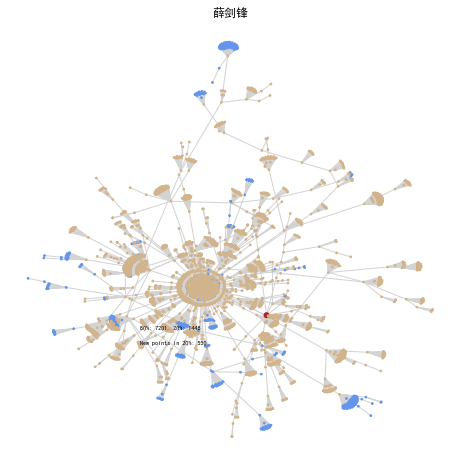

In [159]:
compact_path(G,author,c1,c2)

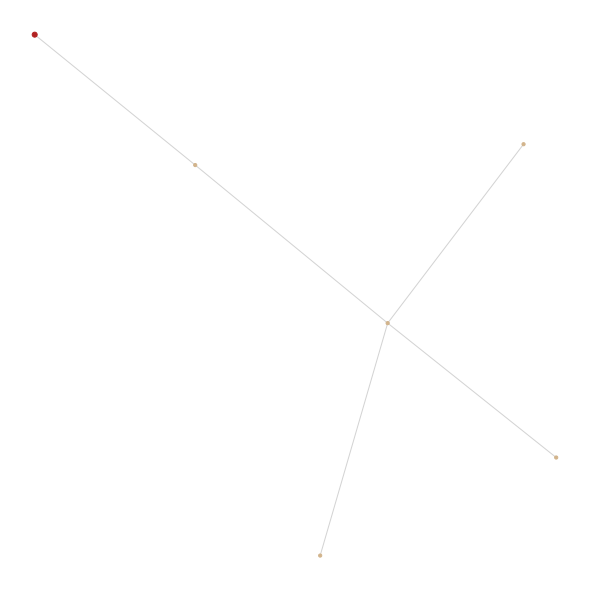

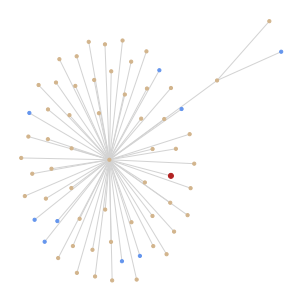

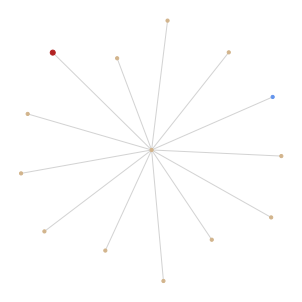

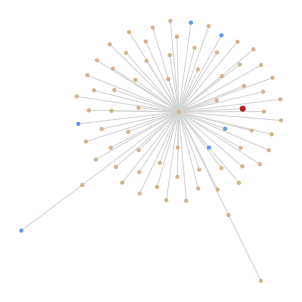

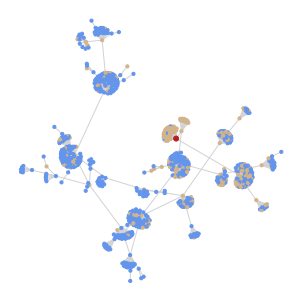

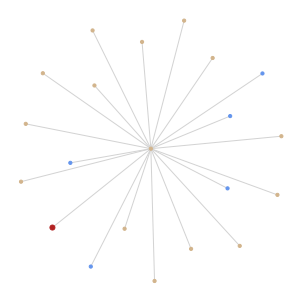

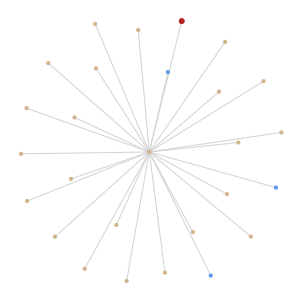

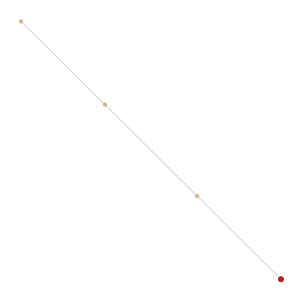

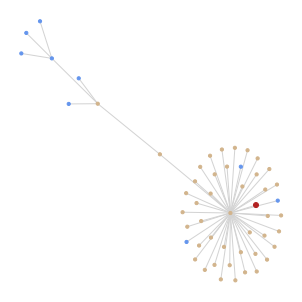

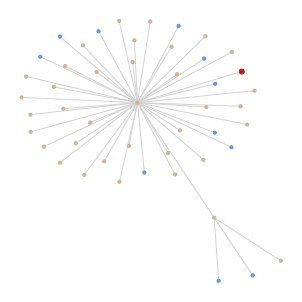

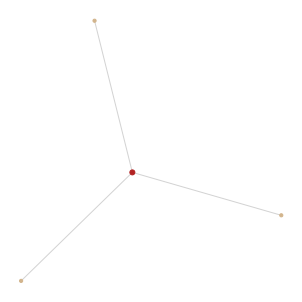

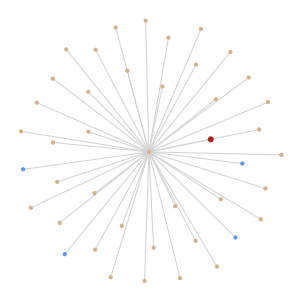

In [160]:
new_path(data,author,new_titles,node_list)

In [6]:
threshold_total_read=0
thershold_common_path_list=[0]
for thershold_common_path in thershold_common_path_list:
    fh=open("CommonPath/node2vec_%d_%.1f.edgelist" %(threshold_total_read, thershold_common_path),'wb')
    author_list=[]
    author_id_list=[]
    node_id_list=[]
    node_list=[]

    ct=0 # node id counter
    c=Counter(data.iloc[:, 2].tolist())
    # author_list, author_count=list(c.keys()), list(c.values())
    for key, value in c.items():
        save_for_later=[]
        save_for_later_1=[]
        # 此处限制条件为，该作者的总阅读数大于等于threshold
        if value>=threshold_total_read:
            node_list.append(key)
            node_id=ct
            node_id_list.append(node_id)
            author_list.append(key)
            author_id=ct
            author_id_list.append(node_id)
            ct+=1
            data_1=data[data.Author==key]
            n_titles=data_1.Title.nunique()
            tree_author=Tree()
            tree_author.create_node(tag=author_id, identifier=author_id, data = Label(0,0))
            layers=data_1.Layer.tolist()
            max_layer=max(layers)
            avg_layer=sum(layers) / len(layers) 

            layer=1
            visited, visited_id=[], []
            while layer<max_layer+1:
                for index, row in data_1.iterrows():
                    if row.Layer==layer:
                        WNN=row.Wechat_NN
                        if WNN not in visited:
                            node_id=ct
                            node_id_list.append(node_id)
                            node_list.append(f"{author_id} {WNN}")

                            if row.Layer==1: 
                                tree_author.create_node(tag=node_id, identifier=node_id, parent = author_id, data = Label(layer,row.Read))
                            else: 
                                try:
                                    p_id=node_list.index(f"{author_id} {row.Belong2}")
                                    tree_author.create_node(tag=node_id, identifier=node_id, parent = p_id, data = Label(layer,row.Read))
                                except:
                                    save_for_later.append([node_id,f"{author_id} {row.Belong2}",layer,row.Read])
                            visited.append(WNN)
                            visited_id.append(node_id)
                            ct+=1
                        else:
                            try:
                                node_id=visited_id[visited.index(WNN)]
                                tree_author.nodes[node_id].data.count+=1
                                tree_author.nodes[node_id].data.read+=row.Read
                            except:
                                save_for_later_1.append([f"{author_id} {WNN}",row.Read])
                layer+=1
            for nid in save_for_later:
                p_id=node_list.index(nid[1])
                tree_author.create_node(tag=nid[0], identifier=nid[0], parent = p_id, data = Label(nid[2],nid[3]))
            for nn in save_for_later_1:
                node_id=node_list.index(nn[0])
                tree_author.nodes[node_id].data.count+=1
                tree_author.nodes[node_id].data.read+=nn[1]

            sum_up(author_id) 
            # tree_author.show()
            # tree_author.show(data_property = 'count')           
            # tree_author.show(data_property = 'read')

            G = nx.Graph()
            # G.add_node(author)
            visit=[author_id]
            
            while len(visit)>0:
                cur=visit[-1]
                if cur==author_id: 
                    G.add_node(cur,weight=tree_author.nodes[cur].data.read)
                    visit.pop()
                    children_list=tree_author.children(cur)
                    for i in children_list:
                        visit.append(i.identifier)  
                elif tree_author.nodes[cur].data.count>=n_titles*thershold_common_path:
                    G.add_node(cur,weight=(tree_author.nodes[cur].data.read))
                    G.add_edge(cur,tree_author.parent(cur).identifier,weight=(tree_author.nodes[cur].data.count))
                    visit.pop()
                    children_list=tree_author.children(cur)
                    for i in children_list:
                        visit.append(i.identifier) 
                else: visit.pop()

    #         pos = nx.circular_layout(G)
    #         plt.clf()
    #         edges = G.edges()
    #         node_weight=[]
    #         node_label=[]
    #         node_color=['bisque']+['lightblue']*(len(G.nodes())-1)
    #         for i in list(G.nodes(data='weight')):
    #             node_weight.append(i[1]/10)
    #             node_label.append(i[1])
    #         edge_weight=[]
    #         edge_label=[]
    #         edge_color=[]
    #         for i in list(G.edges(data='weight')):
    #             edge_weight.append(i[2]/15)
    #             edge_label.append(i[2])
    #             if i[2]>39: edge_color.append('mediumaquamarine')
    #             else: edge_color.append('tan')
    #         options = {'font_size':8,'font_weight':'ultralight',}
    #         node_label=dict(zip(list(G.nodes()),node_label))
    #         edge_label=dict(zip(list(G.edges),edge_label))
    #         try:
    #             pos = nx.nx_agraph.graphviz_layout(G)
    #         except:
    #             pos = nx.spring_layout(G, iterations=20)
    #         plt.title(author)
    #         nx.draw(G, pos, edges=edges,edge_color=edge_color,node_size=node_weight, node_color=node_color,labels=node_label, width=edge_weight, **options)
    #         nx.draw_networkx_edge_labels(G, pos,edge_labels=edge_label,label_pos=0.5,font_size=5,font_weight='ultralight',bbox={"fc":"w","alpha":0.9,"pad":0,"edgecolor":"white"})
    #         plt.text(0.25, 1.1, "Max Layer: %s, Avg Layer: %.2f" %(max_layer,avg_layer), size = 8)
    #         plt.text(0.25, 1.0, "Node label: Read, Edge label: Count", size = 8)
    #         plt.text(0.25, 0.9, "Threshold: 20, 40", size = 8)
    #         plt.savefig("CommonPath/Common_Path_Graph_%s.png" %author, format="PNG",dpi=600)

            nx.write_edgelist(G, fh, data=['weight'], delimiter=",")

    fh.close()
    author_info=list(zip(author_list,author_id_list))
    author_info=pd.DataFrame(data=author_info)
    author_info.to_csv("CommonPath/node2vec_%d_%.1f.authorlist" %(threshold_total_read, thershold_common_path), header=None, index=False)


In [15]:
df_author = []
df_new_points = [] # count for new points
df_reached = [] # count for reached points
df_covered_in_new = [] # count for reached points in new points

for author in data["Author"].drop_duplicates():
    rate = 0.8
    [tree, c1, c2, c3, new_titles, node_list] = author_tree(data, author, rate)
    df_author.append(author)
    df_new_points.append(c1)
    df_reached.append(c2)
    df_covered_in_new.append(c3)

df = pd.DataFrame({'Author':df_author, 'num_New': df_new_points, 'num_Old': df_reached, 'num_Cov_in_New': df_covered_in_new})
df.to_csv("mingjiang/CommonPath/Stat.csv")